In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import math
import matplotlib as mpl
import numpy as np
import os
from pandas.tseries.offsets import DateOffset
import matplotlib.gridspec as gridspec
from datetime import datetime
import warnings
from matplotlib.cm import get_cmap

In [2]:
# Inputs
geodata = pd.read_csv('../state_model/GeoData.txt', index_col=0, sep='\t')
swe  = pd.read_csv('../hist_data/timeUPSNOW_DD.txt', sep='\t', skiprows=1, index_col=0)
cilv = pd.read_csv('../hist_data/timeCILV_DD.txt', sep='\t', skiprows=1, index_col=0)
prec = pd.read_csv('../hist_data/timeCPRC_DD.txt', sep='\t', skiprows=1, index_col=0)
cout = pd.read_csv('~/research/SMM_Models/hype/model/v10_model/final_model/hds_v3/results/timeCOUT_DD.txt', sep='\t', skiprows=1, index_col=0)
output_path = "./new_plots/"

# Analysis period
date_start = "1985-01-01"
date_end   = "2015-12-31"

# Per-region streamflow accumulation windows (used in scatter plots)
season_windows = {
    'Milk River': {'start': (2, 1), 'end': (5, 31)},
    'St. Mary':   {'start': (4, 1), 'end': (7, 31)},
}

# Reference dates for common x-axis (weeks from Feb 1)
feb1_ref    = pd.Timestamp(2000, 2, 1)
apr1_ref    = pd.Timestamp(2000, 4, 1)
oct1_ref    = pd.Timestamp(2000, 10, 1)  # Apr 1 + 6 months
apr1_week   = int(round((apr1_ref - feb1_ref).days / 7))    # ≈ 8 weeks
total_weeks = int(round((oct1_ref - feb1_ref).days / 7))    # ≈ 35 weeks

# Gauges
gauge_ids = [58208, 58213, 58290, 58308, 58356, 58363]

hype_id_to_location = {
    '0058328': ('Milk River', 'BCBMO'),
    '0058346': ('Milk River', 'BSCMO'),
    '0058363': ('Milk River', 'BTCIB'),
    '0058425': ('Milk River', 'CLCMO'),
    '0058290': ('Milk River', 'FRRIB'),
    '0058356': ('Milk River', 'LDCIB'),
    '0058408': ('Milk River', 'MRWIB'),
    '0058643': ('Milk River', 'NFKMR'),
    '0058418': ('Milk River', 'PPCMO'),
    '0058398': ('Milk River', 'RKCMO'),
    '0058213': ('St. Mary', 'SMRBB'),
    '0058208': ('St. Mary', 'SMRIB'),
    '0058223': ('St. Mary', 'SWCSB'),
    '0058308': ('Milk River', 'MREIB'),
    '0058242': ('Milk River', 'Outlet')
}


In [3]:
# Format data
geodata['maindown'] = geodata['maindown'].astype(int)
geodata.index = geodata.index.astype(int)

swe.index  = pd.to_datetime(swe.index)
cilv.index = pd.to_datetime(cilv.index)
prec.index = pd.to_datetime(prec.index)
cout.index = pd.to_datetime(cout.index)

swe.columns  = swe.columns.astype(int)
cilv.columns = cilv.columns.astype(int)
prec.columns = prec.columns.astype(int)
cout.columns = cout.columns.astype(int)

subbasin_area = geodata["area"].to_dict()

swe  = swe.loc[date_start:date_end]
cilv = cilv.loc[date_start:date_end]
prec = prec.loc[date_start:date_end]
cout = cout.loc[date_start:date_end]

### Scatter Plot

In [4]:
# Helper: look up region for a gauge
def get_gauge_region(gauge_id):
    gauge_str = str(gauge_id).zfill(7)
    return hype_id_to_location[gauge_str][0] if gauge_str in hype_id_to_location else None

# Antecedent date per region:
#   Milk River → Feb 1 (pre-melt snowpack)
#   St. Mary   → Apr 1 (later melt timing)
start_year = pd.to_datetime(date_start).year
end_year   = pd.to_datetime(date_end).year

antecedent_dates = {
    'Milk River': pd.to_datetime([f"{y}-02-01" for y in range(start_year, end_year + 1)]),
    'St. Mary':   pd.to_datetime([f"{y}-04-01" for y in range(start_year, end_year + 1)]),
}
antecedent_month_day = {
    'Milk River': (2, 1),
    'St. Mary':   (4, 1),
}
# Antecedent date label per region (for axis labels)
antecedent_date_label = {
    'Milk River': 'Feb 1',
    'St. Mary':   'Apr 1',
}

In [5]:
# Build directed river graph
riv_graph = nx.DiGraph()
for idx, row in geodata.iterrows():
    if row['maindown'] != 0:
        riv_graph.add_edge(idx, row['maindown'])

# --- Results loop: scatter plot data ---
results = {}
for gauge_id in gauge_ids:
    if gauge_id not in riv_graph.nodes:
        print(f"{gauge_id} not found in river graph.")
        results[gauge_id] = None
        continue
    if gauge_id not in cout.columns or gauge_id not in swe.columns:
        results[gauge_id] = None
        continue

    region  = get_gauge_region(gauge_id)
    win     = season_windows[region]
    r_start = win['start']
    r_end   = win['end']

    cout_gauge = cout[[gauge_id]].copy()

    # --- Seasonal streamflow sum using region-specific window ---
    seasonal_sums = cout_gauge.groupby(cout_gauge.index.year).apply(
        lambda df: df.loc[
            ((df.index.month > r_start[0]) |
             ((df.index.month == r_start[0]) & (df.index.day >= r_start[1]))) &
            ((df.index.month < r_end[0]) |
             ((df.index.month == r_end[0]) & (df.index.day <= r_end[1]))),
            gauge_id
        ].sum()
    )
    seasonal_sums = seasonal_sums.to_frame(name="seasonal_sum")
    seasonal_sums["seasonal_rank"] = seasonal_sums["seasonal_sum"].rank(ascending=True).astype(int)

    # --- Antecedent SWE — date depends on region ---
    dates      = antecedent_dates[region]
    antecedent = swe[[gauge_id]].reindex(dates).rename(columns={gauge_id: "antecedent_swe"})
    antecedent["antecedent_rank"] = antecedent["antecedent_swe"].rank(ascending=True).astype(int)
    antecedent.index = antecedent.index.year

    combined = seasonal_sums.merge(antecedent, left_index=True, right_index=True, how="left")
    results[gauge_id] = combined

### Lead Time

In [6]:
# --- Lead time R² loop ---
#lead_times = {f'{w}w': pd.DateOffset(weeks=w) for w in range(1, 17)}
# --- Lead time R² loop ---
# x-axis: weeks from Feb 1 (common reference for all gauges)
# St. Mary data only starts at week ~8 (when Apr 1 is reached)
r2_results = {gauge_id: [np.nan] * total_weeks for gauge_id in gauge_ids}

for w in range(1, total_weeks + 1):
    for gauge_id in gauge_ids:
        if gauge_id not in riv_graph.nodes or gauge_id not in cout.columns:
            continue  # leave as NaN

        region = get_gauge_region(gauge_id)

        # St. Mary starts from Apr 1 — no data before that on x-axis
        if region == 'St. Mary' and w <= apr1_week:
            continue  # leave as NaN

        # Window start depends on region
        if region == 'Milk River':
            loop_start = feb1_ref
            loop_end   = feb1_ref + pd.DateOffset(weeks=w)
        else:  # St. Mary
            loop_start = apr1_ref
            loop_end   = apr1_ref + pd.DateOffset(weeks=w - apr1_week)

        start_md = (loop_start.month, loop_start.day)
        end_md   = (loop_end.month,   loop_end.day)

        cout_gauge = cout[[gauge_id]].copy()
        seasonal_sums = cout_gauge.groupby(cout_gauge.index.year).apply(
            lambda df: df.loc[
                ((df.index.month > start_md[0]) |
                 ((df.index.month == start_md[0]) & (df.index.day >= start_md[1]))) &
                ((df.index.month < end_md[0]) |
                 ((df.index.month == end_md[0]) & (df.index.day <= end_md[1]))),
                gauge_id
            ].sum()
        )
        seasonal_sums = seasonal_sums.to_frame(name="seasonal_sum")
        seasonal_sums["seasonal_rank"] = seasonal_sums["seasonal_sum"].rank(ascending=True).astype(int)

        if gauge_id not in swe.columns:
            continue
        dates      = antecedent_dates[region]
        antecedent = swe[[gauge_id]].reindex(dates).rename(columns={gauge_id: "antecedent_swe"})
        antecedent["antecedent_rank"] = antecedent["antecedent_swe"].rank(ascending=True).astype(int)
        antecedent.index = antecedent.index.year

        combined_tmp = seasonal_sums.merge(
            antecedent[["antecedent_rank"]], left_index=True, right_index=True, how="left"
        )
        valid_mask = combined_tmp[["antecedent_rank", "seasonal_rank"]].notna().all(axis=1)
        r2_results[gauge_id][w - 1] = (
            r2_score(combined_tmp.loc[valid_mask, "antecedent_rank"],
                     combined_tmp.loc[valid_mask, "seasonal_rank"])
            if valid_mask.sum() > 1 else np.nan
        )

### Combined Plot

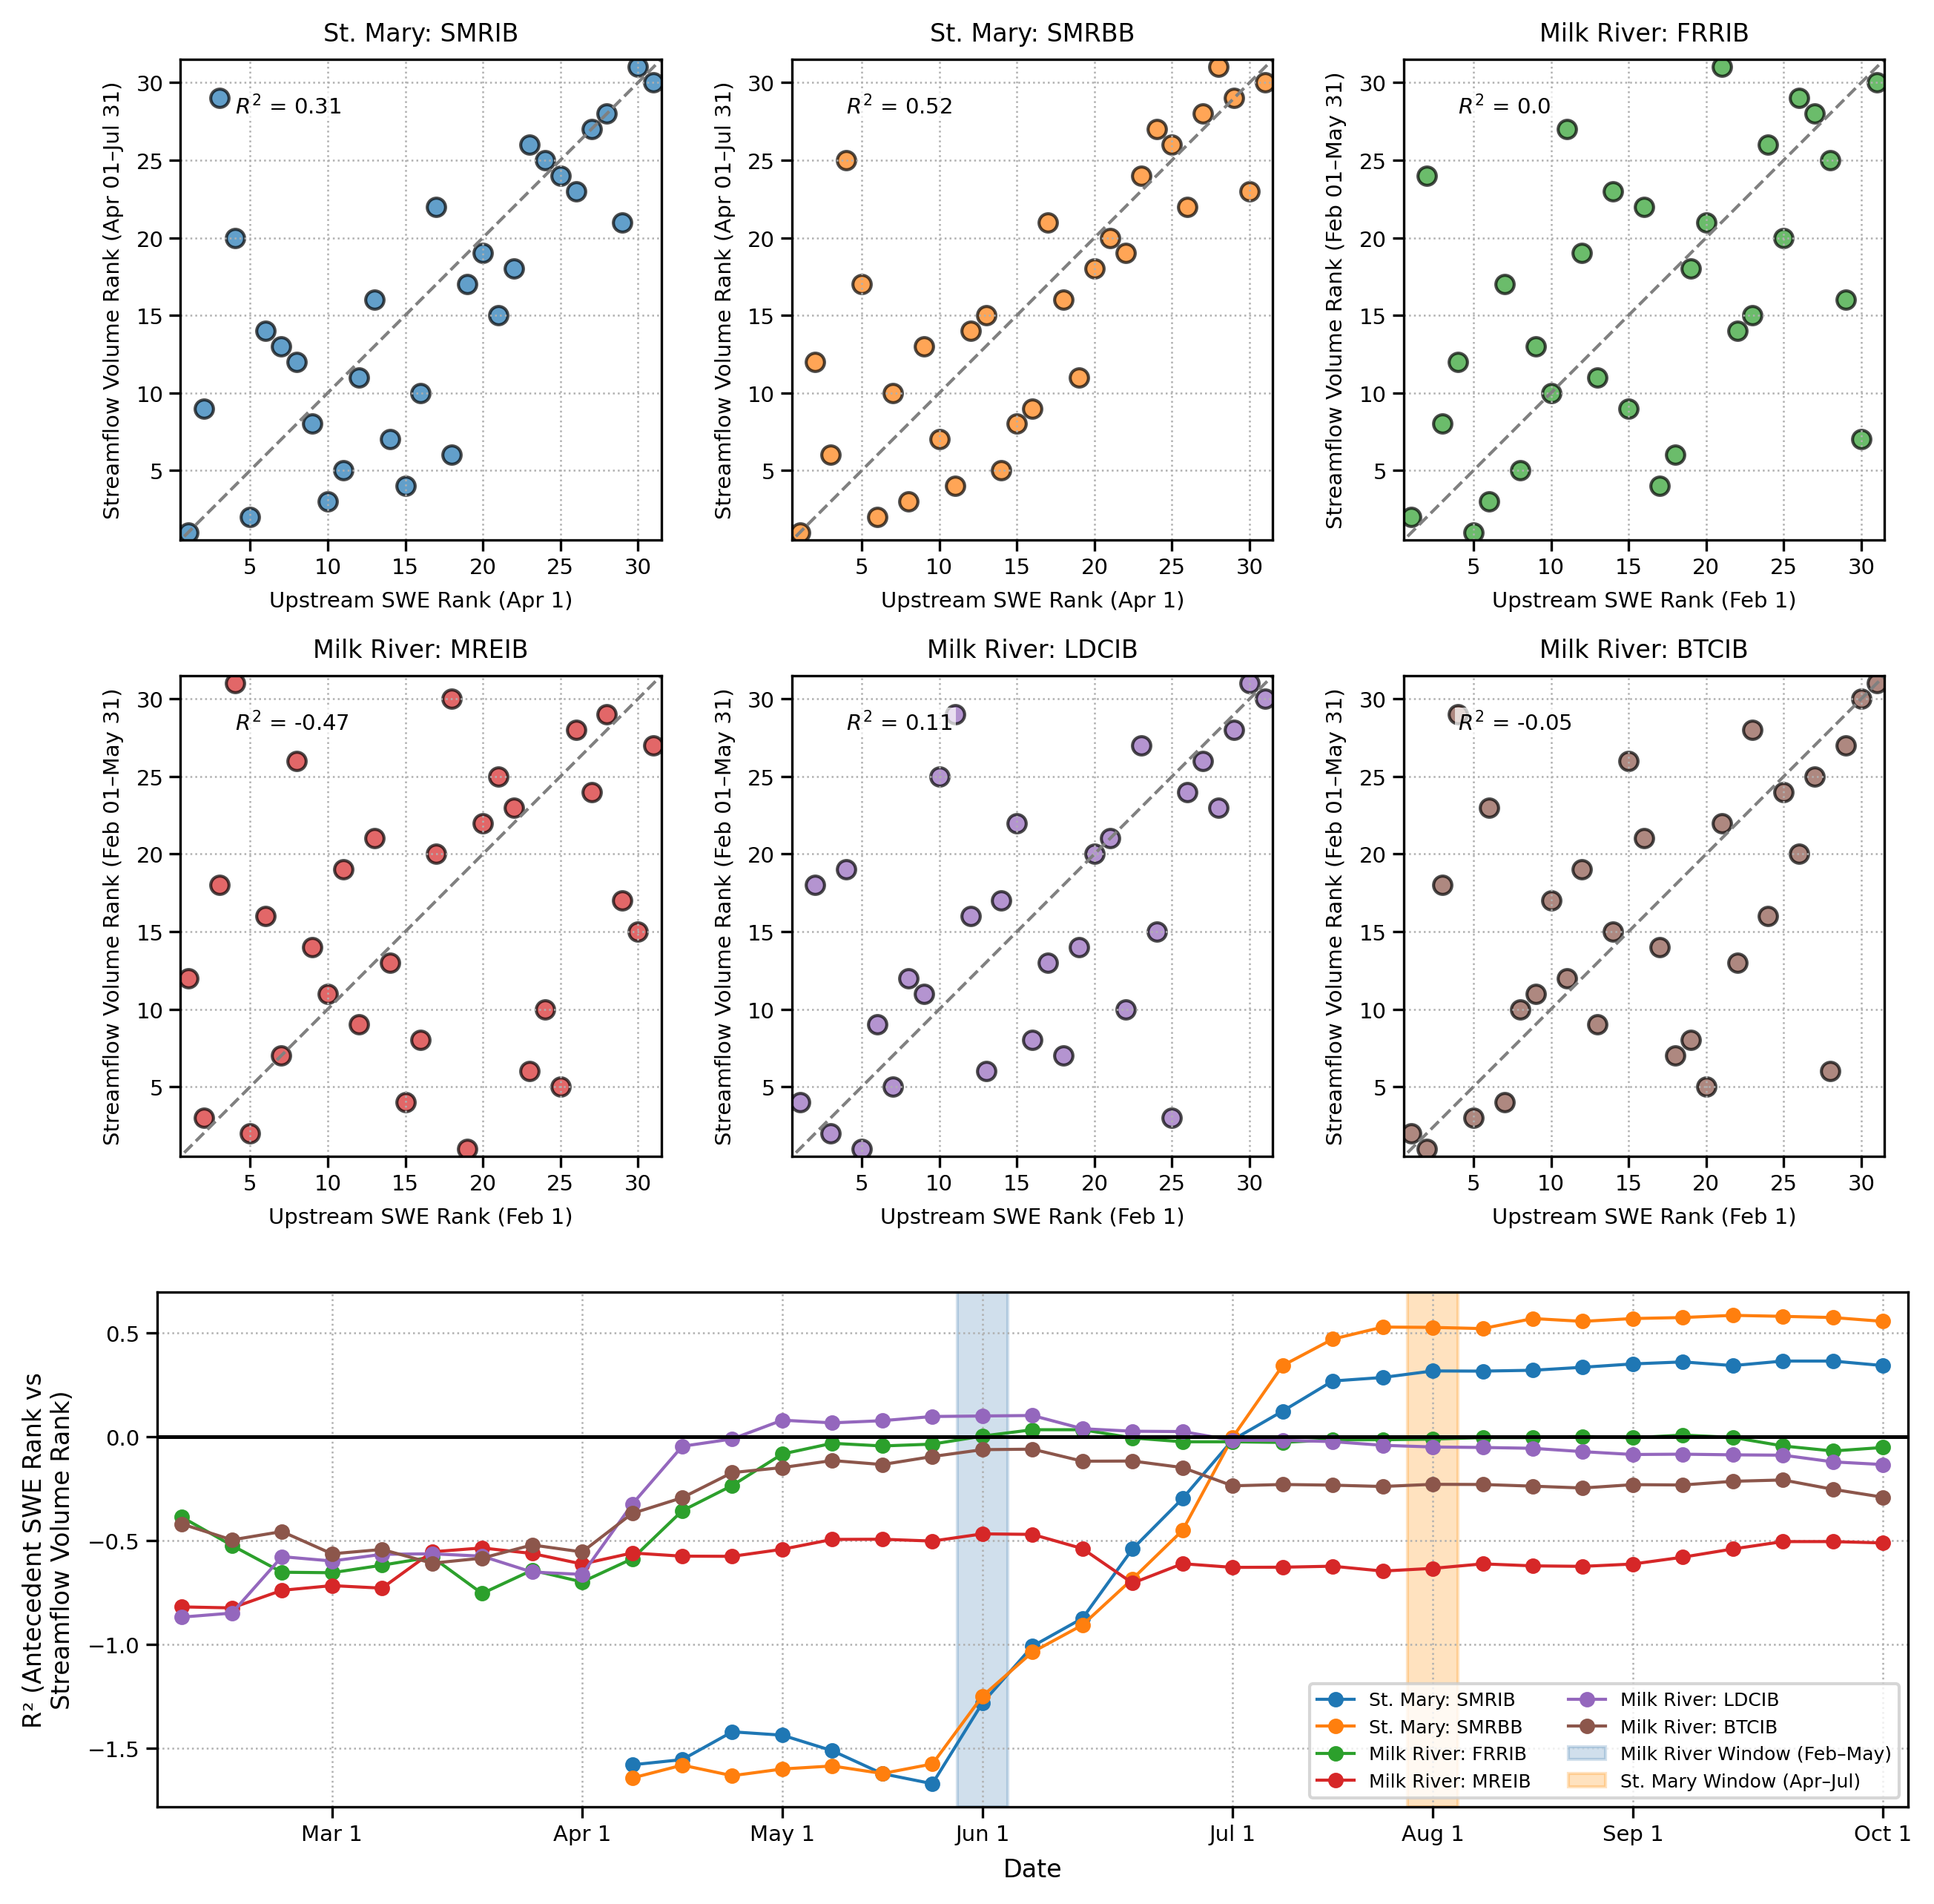

In [8]:
# # --- Runoff window for shading ---
# season_start_ts = pd.Timestamp(year=2000, month=season_start_tuple[0], day=season_start_tuple[1])
# season_end_ts   = pd.Timestamp(year=2000, month=season_end_tuple[0],   day=season_end_tuple[1])
# delta_days = (season_end_ts - season_start_ts).days
# lead_week  = delta_days / 7
# if not float(lead_week).is_integer():
#     warnings.warn(
#         f"Runoff window ({season_start_tuple}–{season_end_tuple}) is not an exact number of weeks. "
#         f"Rounding from {lead_week:.2f} weeks to nearest integer."
#     )
# lead_week = int(round(lead_week))

# --- Matplotlib styling ---
mpl.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.dpi': 300,
    'lines.linewidth': 1.2,
    'xtick.major.pad': 2,
    'ytick.major.pad': 2,
    'legend.frameon': False
})

# --- Figure layout ---
column_width   = 3.5
ncols          = 3
num_gauges     = len(gauge_ids)
nrows          = int(np.ceil(num_gauges / ncols))
height_scatter = 2.8
height_r2      = 3.0
fig_width      = column_width * 2.5
fig_height     = nrows * height_scatter + height_r2

fig = plt.figure(figsize=(fig_width, fig_height))
gs  = gridspec.GridSpec(nrows=nrows + 1, ncols=ncols,
                        height_ratios=[height_scatter] * nrows + [height_r2])

cmap   = plt.colormaps['tab10']
colors = [cmap(i % 10) for i in range(num_gauges)]

# --- Scatter plots ---
scatter_axes = []
for idx, gauge_id in enumerate(gauge_ids):
    ax = fig.add_subplot(gs[idx // ncols, idx % ncols])
    scatter_axes.append(ax)

    combined = results[gauge_id]
    if combined is None:
        ax.set_visible(False)
        continue

    # Region-specific window for this gauge
    region = get_gauge_region(gauge_id)
    win    = season_windows[region]

    x = combined["antecedent_rank"]
    y = combined["seasonal_rank"]
    ax.scatter(x, y, color=colors[idx], alpha=0.7, edgecolors='k', s=35)
    max_rank = max(x.max(), y.max())
    ax.plot([0, max_rank + 1], [0, max_rank + 1], '--', color='gray', lw=1)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlim(0.5, max_rank + 0.5)
    ax.set_ylim(0.5, max_rank + 0.5)
    ax.grid(True, linestyle=':', linewidth=0.6)

    # R² annotation
    valid_mask = combined[["antecedent_rank", "seasonal_rank"]].notna().all(axis=1)
    if valid_mask.sum() > 1:
        r2 = np.round(r2_score(combined.loc[valid_mask, "antecedent_rank"],
                               combined.loc[valid_mask, "seasonal_rank"]), 2)
        ax.text(x.min() + 0.1 * (x.max() - x.min()),
                y.max() - 0.1 * (y.max() - y.min()),
                f'$R^2$ = {r2}', fontsize=7,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    # Title
    gauge_str = str(gauge_id).zfill(7)
    if gauge_str in hype_id_to_location:
        info  = hype_id_to_location[gauge_str]
        title = (f"{info[0]}: {info[1]} ({info[2]} km²)"
                 if len(info) == 3 else f"{info[0]}: {info[1]}")
    else:
        title = f"Gauge {gauge_id}"
    ax.set_title(title, fontsize=8)

    # Axis labels
    r_start_ts = pd.Timestamp(2000, *win['start'])
    r_end_ts   = pd.Timestamp(2000, *win['end'])
    date_label = antecedent_date_label[region]
    ax.set_xlabel(f'Upstream SWE Rank ({date_label})', fontsize=7)
    ax.set_ylabel(
        f"Streamflow Volume Rank "
        f"({r_start_ts.strftime('%b %d')}–{r_end_ts.strftime('%b %d')})",
        fontsize=7
    )

# Hide unused scatter axes
for j in range(num_gauges, nrows * ncols):
    fig.add_subplot(gs[j // ncols, j % ncols]).set_visible(False)

# --- R² vs lead time (bottom panel) ---
r2_ax = fig.add_subplot(gs[-1, :])
for idx, (gauge_id, r2_list) in enumerate(r2_results.items()):
    gauge_str = str(gauge_id).zfill(7)
    if gauge_str in hype_id_to_location:
        info  = hype_id_to_location[gauge_str]
        label = f"{info[0]}: {info[1]}"
    else:
        label = f"Gauge {gauge_id}"
    r2_ax.plot(range(1, len(r2_list) + 1), r2_list,
               marker='o', markersize=4, lw=1, color=colors[idx], label=label)

# Shading: weeks from Feb 1 where each region's scatter window ends
milk_end_week   = int(round((pd.Timestamp(2000, *season_windows['Milk River']['end']) - feb1_ref).days / 7))
stmary_end_week = int(round((pd.Timestamp(2000, *season_windows['St. Mary']['end'])   - feb1_ref).days / 7))

r2_ax.axvspan(milk_end_week   - 0.5, milk_end_week   + 0.5,
              color='steelblue',  alpha=0.25, label='Milk River Window (Feb–May)')
r2_ax.axvspan(stmary_end_week - 0.5, stmary_end_week + 0.5,
              color='darkorange', alpha=0.25, label='St. Mary Window (Apr–Jul)')

r2_ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-', zorder=2)


# --- Date labels on x-axis ---
date_ticks = [pd.Timestamp(2000, m, 1) for m in range(3, 11)]  # Mar 1 – Oct 1
tick_positions = [round((t - feb1_ref).days / 7) for t in date_ticks]
tick_labels    = [t.strftime('%b 1') for t in date_ticks]
r2_ax.set_xticks(tick_positions)
r2_ax.set_xticklabels(tick_labels, fontsize=7)

r2_ax.set_xlabel("Date", fontsize=8)
r2_ax.set_ylabel("R² (Antecedent SWE Rank vs\nStreamflow Volume Rank)", fontsize=8)
r2_ax.set_xlim(0.5, total_weeks + 0.5)
r2_ax.autoscale(enable=True, axis='y')
r2_ax.grid(True, linestyle=':', linewidth=0.6)
r2_ax.legend(fontsize=6, ncol=2, loc='lower right', frameon=True)
plt.tight_layout()
os.makedirs(output_path, exist_ok=True)
fig.savefig(os.path.join(output_path, 'fig3_swe_scatter.png'), dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(output_path, 'fig3_swe_scatter.pdf'), format='pdf', bbox_inches='tight')
plt.show()